In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import sys
import time
import os
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [2]:
!pip install xsuite


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.1/759.1 kB 18.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.2/240.2 kB 25.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.8/77.8 kB 8.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 5.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 kB 44

/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


xtrack version 0.101.4
Saved: (200, 4000, 6) (200, 4000, 6) (200, 3)
Dataset shapes: X = (50000, 6) , Y = (50000, 6)
Dataset saved to xsuite_dataset.npz


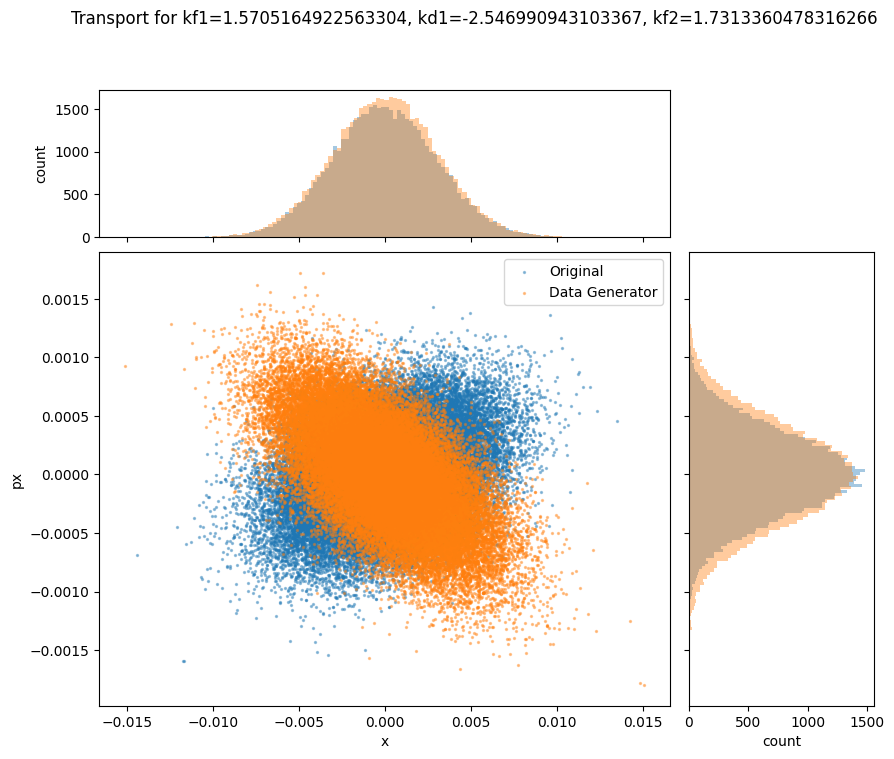

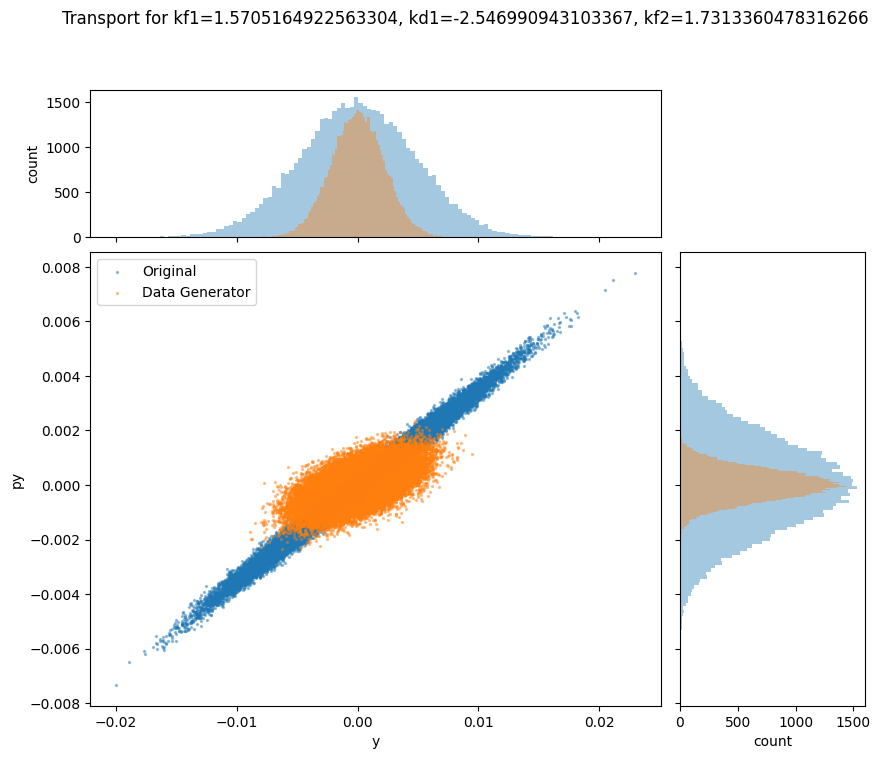

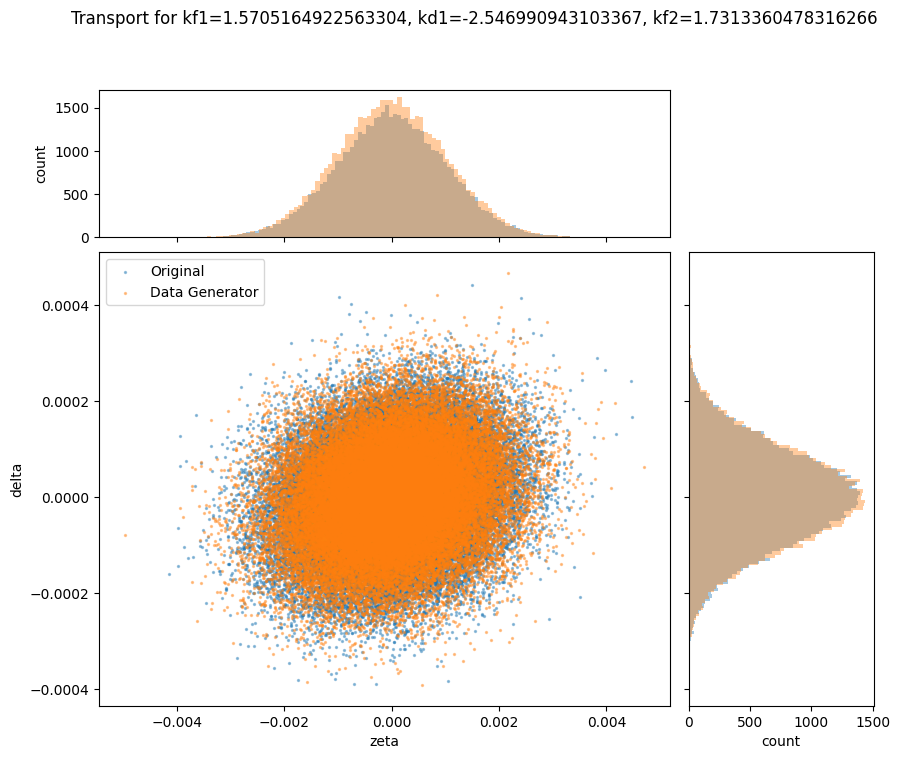

In [3]:
#import useful libraries
import numpy as np  # arrays and math
import matplotlib.pyplot as plt  # plots
import xtrack as xt  # tracking module of Xsuite
#%matplotlib widget

def plot_phase_space_with_profiles(x_array, px_array, title="",axis_labels = None, label=None, bins=120, difference=False)->None:
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(
        2, 2,
        width_ratios=(4, 1.3),
        height_ratios=(1.3, 4),
        hspace=0.05,
        wspace=0.05
    )

    ax_histx = fig.add_subplot(gs[0, 0])
    ax_scatter = fig.add_subplot(gs[1, 0])
    ax_histpx = fig.add_subplot(gs[1, 1])

    # Scatter
    number_of_plots = len(x_array) if isinstance(x_array, list) else 1
    if number_of_plots > 1:
        for i in range(number_of_plots):
            x = x_array[i]
            px = px_array[i]
            lbl = label[i] if label is not None else None
            ax_scatter.scatter(x, px, s=2, alpha=0.4, label=lbl)
    else:
        x = x_array if not isinstance(x_array, list) else x_array[0]
        px = px_array if not isinstance(px_array, list) else px_array[0]

    ax_scatter.set_xlabel("x") if axis_labels is None else ax_scatter.set_xlabel(axis_labels[0])
    ax_scatter.set_ylabel("px") if axis_labels is None else ax_scatter.set_ylabel(axis_labels[1])
    if label is not None:
        ax_scatter.legend()

    # x profile
    if number_of_plots > 1:
        for i in range(number_of_plots):
            x = x_array[i]
            lbl = label[i] if label is not None else None
            ax_histx.hist(x, bins=bins, alpha=0.4, label=lbl)
            if difference and i == 1:  # If difference is True, plot the difference for the second dataset
                x_diff = x - (x_array[0] if not isinstance(x_array[0], list) else x_array[0][i])
                ax_histx.hist(x_diff, bins=bins, alpha=0.4, label=f"{lbl} Difference")

    else:
        x = x_array if not isinstance(x_array, list) else x_array[0]
        ax_histx.hist(x, bins=bins, alpha=0.4)

    ax_histx.set_ylabel("count")
    ax_histx.tick_params(axis="x", labelbottom=False)

    # px profile
    if number_of_plots > 1:
        for i in range(number_of_plots):
            px = px_array[i]
            lbl = label[i] if label is not None else None
            ax_histpx.hist(px, bins=bins, orientation="horizontal", alpha=0.4, label=lbl)
            if difference and i == 1:  # If difference is True, plot the difference for the second dataset
                px_diff = px - (px_array[0] if not isinstance(px_array[0], list) else px_array[0][i])
                ax_histpx.hist(px_diff, bins=bins, orientation="horizontal", alpha=0.4, label=f"{lbl} Difference")
    else:
        px = px_array if not isinstance(px_array, list) else px_array[0]
        ax_histpx.hist(px, bins=bins, orientation="horizontal", alpha=0.4)

    ax_histpx.set_xlabel("count")
    ax_histpx.tick_params(axis="y", labelleft=False)

    fig.suptitle(title)
    plt.show()


##################################

print('xtrack version', xt.__version__)

# Reference energy


part = xt.Particles(mass0=xt.PROTON_MASS_EV, p0c=1e9)  # Mass eV/c^2 Momentum in eV/c

# Element geometry
env=xt.Environment()
env.vars.default_to_zero = True
env['l_mq'] = 0.4


env.new('mq', xt.Quadrupole, length='l_mq')
env.new('qf1', 'mq', k1='kf1') # Focusing quadrupole  k1>0
env.new('qf2', 'mq', k1='kf2') # Focusing quadrupole  k1>0
env.new('qd1', 'mq', k1='kd1') # De-focusing quadrupole k1<0
#Markers
env.new("start_cell",xt.Marker)
env.new("end_cell",xt.Marker)


line = env.new_line(
    length=4, # 4 m length
    components=[
    env.place('start_cell', at=0),
    env.place('qf1', at=1),
    env.place('qd1', at=2),   # refer to the center by default
    env.place('qf2', at=3),
    env.place('end_cell',at=4),
    ]
)
line.particle_ref=part
line.build_tracker()


kf1 = 1.0; kd1 = -1.0 ; kf2 = 1.0

env['kf1'] = kf1
env['kd1'] = kd1
env['kf2'] = kf2

rng = np.random.default_rng(56)
n_particles = 50000

p0 = line.build_particles(
    x     = rng.normal(0.0, 1e-3, n_particles),
    y     = rng.normal(0.0, 1e-3, n_particles),
    zeta  = rng.normal(0.0, 1e-3, n_particles),
    px    = rng.normal(0.0, 1e-3, n_particles),
    py    = rng.normal(0.0, 1e-3, n_particles),
    delta = rng.normal(0.0, 1e-4, n_particles)
)
line.track(p0, turn_by_turn_monitor="ONE_TURN_EBE")





def sample_initial_conditions(n_particles: int, rng: np.random.Generator) -> np.ndarray:
    x     = rng.normal(0.0, 1e-3, n_particles)
    y     = rng.normal(0.0, 1e-3, n_particles)
    zeta  = rng.normal(0.0, 1e-3, n_particles)
    px    = rng.normal(0.0, 1e-3, n_particles)
    py    = rng.normal(0.0, 1e-3, n_particles)
    delta = rng.normal(0.0, 1e-4, n_particles)

    ## it must be separated as {[x0,y0,zeta0,px0,py0,delta0], [x1,y1,zeta1,px1,py1,delta1], ...} -> column stack

    return np.column_stack([x, y, zeta, px, py, delta]).astype(np.float64)

def particles_to_6d(particles: xt.Particles) -> np.ndarray:
    # Henon order: [q, p] = [x, y, zeta, px, py, delta]
    return np.column_stack([
        np.array(particles.x),
        np.array(particles.y),
        np.array(particles.zeta),
        np.array(particles.px),
        np.array(particles.py),
        np.array(particles.delta),
    ]).astype(np.float64)


def data_builder(line: xt.Line,
                 env,
                 total_particles=50000,
                 seed=42,
                 kf1_range=(0.2, 1.5),
                 kd1_range=(-2.5, -0.2),
                 kf2_range=(0.2, 1.5),
                 quad_iterations=1,
                 save_params=True) -> dict:

    rng = np.random.default_rng(seed)
    X_all, Y_all = [], []
    sampled_params = []

    for _ in range(quad_iterations):
        kf1 = rng.uniform(*kf1_range)
        kd1 = rng.uniform(*kd1_range)
        kf2 = rng.uniform(*kf2_range)

        env['kf1'] = kf1
        env['kd1'] = kd1
        env['kf2'] = kf2

        z0 = sample_initial_conditions(total_particles, rng)

        p = line.build_particles(
            x=z0[:, 0],
            y=z0[:, 1],
            zeta=z0[:, 2],
            px=z0[:, 3],
            py=z0[:, 4],
            delta=z0[:, 5],
        )

        line.track(p)

        z1 = particles_to_6d(p)

        mu = np.tile(np.array([kf1, kd1, kf2], dtype=np.float64), (total_particles, 1))
        X_batch = np.hstack([z0, mu]) if save_params else z0
        Y_batch = z1

        X_all.append(X_batch)
        Y_all.append(Y_batch)
        sampled_params.append((kf1, kd1, kf2))

    X = np.vstack(X_all)
    Y = np.vstack(Y_all)

    perm = rng.permutation(X.shape[0])   # fixed
    X = X[perm]
    Y = Y[perm]

    np.savez("xsuite_dataset.npz", X=X, Y=Y)
    print("Dataset shapes: X =", X.shape, ", Y =", Y.shape)
    print("Dataset saved to xsuite_dataset.npz")

    return {"X": X, "Y": Y, "params": sampled_params}

def build_operator_dataset(
    line,
    env,
    n_samples=2000,
    particles_per_sample=4000,
    seed=42,
    kf1_range=(0.1, 2.0),
    kd1_range=(-4.5, -0.05),
    kf2_range=(0.1, 2.0),
    ):
    rng = np.random.default_rng(seed)

    X_samples = []
    Y_samples = []
    MU_samples = []

    for _ in range(n_samples):
        kf1 = rng.uniform(*kf1_range)
        kd1 = rng.uniform(*kd1_range)
        kf2 = rng.uniform(*kf2_range)

        env["kf1"] = kf1
        env["kd1"] = kd1
        env["kf2"] = kf2

        z0 = sample_initial_conditions(particles_per_sample, rng)

        p = line.build_particles(
            x=z0[:, 0],
            y=z0[:, 1],
            zeta=z0[:, 2],
            px=z0[:, 3],
            py=z0[:, 4],
            delta=z0[:, 5],
        )
        line.track(p)
        z1 = particles_to_6d(p)

        X_samples.append(z0.astype(np.float32))          # [Np, 6]
        Y_samples.append(z1.astype(np.float32))          # [Np, 6]
        MU_samples.append(np.array([kf1, kd1, kf2], dtype=np.float32))

    X_samples = np.stack(X_samples, axis=0)   # [Ns, Np, 6]
    Y_samples = np.stack(Y_samples, axis=0)   # [Ns, Np, 6]
    MU_samples = np.stack(MU_samples, axis=0) # [Ns, 3]

    np.savez("xsuite_operator_dataset.npz", X=X_samples, Y=Y_samples, MU=MU_samples)
    print("Saved:", X_samples.shape, Y_samples.shape, MU_samples.shape)


# in generate_dataset.py
build_operator_dataset(
        line,
        env,
        n_samples=200,
        particles_per_sample=4000,
        seed=42,
        kf1_range=(0.1, 2.0),
        kd1_range=(-4.5, -0.05),
        kf2_range=(0.1, 2.0),
    )

data = data_builder(line,
             env,
             total_particles=50000,
             seed=42,
             kf1_range=(0.1, 2),
             kd1_range=(-4.5, -0.05),
             kf2_range=(0.1, 2),
             quad_iterations=1,
             save_params=False)


z_in_raw = data["X"]
z_out_raw = data["Y"]


x_data_generator = z_out_raw[:, 0]
px_data_generator = z_out_raw[:, 3]
y_data_generator = z_out_raw[:, 1]
py_data_generator = z_out_raw[:, 4]
zeta_data_generator = z_out_raw[:, 2]
delta_data_generator = z_out_raw[:, 5]

x = np.array(p0.x)
px = np.array(p0.px)
y = np.array(p0.y)
py = np.array(p0.py)
zeta = np.array(p0.zeta)
delta = np.array(p0.delta)

x_array = [x, x_data_generator]
px_array = [px, px_data_generator]
y_array = [y, y_data_generator]
py_array = [py, py_data_generator]
zeta_array = [zeta, zeta_data_generator]
delta_array = [delta, delta_data_generator]

label = ["Original", "Data Generator"]
x_axis_array = [x_array, y_array, zeta_array]
px_axis_array = [px_array, py_array, delta_array]

axis_labels = [["x", "px"] , ["y", "py"], ["zeta", "delta"]]

axis_index = 1 # 0 for x-px, 1 for y-py, 2 for zeta-delta

for axis_index in range(3):
    plot_phase_space_with_profiles(x_axis_array[axis_index], px_axis_array[axis_index], title=f"Transport for kf1={env['kf1']}, kd1={env['kd1']}, kf2={env['kf2']}", axis_labels=axis_labels[axis_index], label=label, difference=False)



In [4]:

tf.keras.backend.set_floatx('float64')
keras.backend.set_floatx('float64')


In [45]:
class SymplecticScaler(layers.Layer):
    def __init__(self, dim=1, mu_dim=0, learn_center=True):
        super().__init__(dtype='float64')
        self.dim = dim
        self.mu_dim = mu_dim
        self.learn_center = learn_center

    def build(self, input_shape):
        self.log_s = self.add_weight(
            shape=(self.dim,),
            initializer='zeros',
            dtype='float64',
            trainable=True,
            name='log_s'
        )
        if self.learn_center:
            self.cq = self.add_weight(
                shape=(self.dim,),
                initializer='zeros',
                dtype='float64',
                trainable=True,
                name='cq'
            )
            self.cp = self.add_weight(
                shape=(self.dim,),
                initializer='zeros',
                dtype='float64',
                trainable=True,
                name='cp'
            )
        super().build(input_shape)

    def call(self, zfull):
        zfull = tf.cast(zfull, tf.float64)
        z_phase = zfull[:, :2*self.dim]
        mu = zfull[:, 2*self.dim:] if self.mu_dim > 0 else None

        q = z_phase[:, :self.dim]
        p = z_phase[:, self.dim:]

        s = tf.exp(self.log_s)[None, :]

        if self.learn_center:
            q = q - self.cq[None, :]
            p = p - self.cp[None, :]

        qn = q / s
        pn = p * s
        z_phase_n = tf.concat([qn, pn], axis=1)

        if self.mu_dim > 0:
            return tf.concat([z_phase_n, mu], axis=1)
        return z_phase_n

    def inverse_map(self, zfull):
        zfull = tf.cast(zfull, tf.float64)
        z_phase = zfull[:, :2*self.dim]
        mu = zfull[:, 2*self.dim:] if self.mu_dim > 0 else None

        qn = z_phase[:, :self.dim]
        pn = z_phase[:, self.dim:]

        s = tf.exp(self.log_s)[None, :]

        q = qn * s
        p = pn / s

        if self.learn_center:
            q = q + self.cq[None, :]
            p = p + self.cp[None, :]

        z_phase_out = tf.concat([q, p], axis=1)

        if self.mu_dim > 0:
            return tf.concat([z_phase_out, mu], axis=1)
        return z_phase_out

In [46]:

###### Henon Map
def HenonMap(X, Y, mu, Win, Wout, bin, eta):
    with tf.GradientTape() as tape:
        tape.watch(Y)
        Ylast = (Y - 0.0) / np.pi
        Y_V = tf.concat([Ylast, mu], axis=1) if mu is not None else Ylast
        hidden = tf.math.tanh(tf.linalg.matmul(Y_V, Win) + bin)   # bin shape [ni]
        V = tf.linalg.matmul(hidden, Wout)                        # [batch, 1]

    Xout = Y + eta                                               # eta shape [dim]
    Yout = -X + tape.gradient(V, Y)
    return Xout, Yout
'''Define a Henon layer'''
class HenonLayer(layers.Layer):
    def __init__(self, ni, dim=3, mu_dim=0):
        super().__init__()
        self.dim = dim
        self.mu_dim = mu_dim
        self.ni = ni
        self.init = tf.initializers.GlorotNormal()

    def build(self, input_shape):
        in_dim = self.dim + self.mu_dim

        self.Win = self.add_weight(
            name="Win",
            shape=(in_dim, self.ni),
            initializer=self.init,
            dtype=tf.float64,
            trainable=True,
        )
        self.Wout = self.add_weight(
            name="Wout",
            shape=(self.ni, 1),
            initializer=self.init,
            dtype=tf.float64,
            trainable=True,
        )
        self.bin = self.add_weight(
            name="bin",
            shape=(self.ni,),
            initializer="zeros",
            dtype=tf.float64,
            trainable=True,
        )
        self.eta = self.add_weight(
            name="eta",
            shape=(self.dim,),
            initializer="zeros",
            dtype=tf.float64,
            trainable=True,
        )
        super().build(input_shape)

    def call(self, z):
        d = self.dim
        x = z[:, :d]
        y = z[:, d:2*d]
        mu = z[:, 2*d:] if z.shape[1] > 2*d else None

        xnext, ynext = HenonMap(x, y, mu, self.Win, self.Wout, self.bin, self.eta)
        xnext, ynext = HenonMap(xnext, ynext, mu, self.Win, self.Wout, self.bin, self.eta)
        xnext, ynext = HenonMap(xnext, ynext, mu, self.Win, self.Wout, self.bin, self.eta)
        xnext, ynext = HenonMap(xnext, ynext, mu, self.Win, self.Wout, self.bin, self.eta)
        return tf.concat([xnext, ynext], axis=1)

'''Define a HenonNet'''
class HenonNet(Model):
    def __init__(self,unit_list,dim = 3):#
        super(HenonNet, self).__init__()
        self.N = len(unit_list)
        # Keep a Python list for easy iteration, but ALSO assign each
        # sublayer as an attribute on `self` so Keras will register it
        # as a tracked sublayer (and expose its variables).
        self.hlayers = []
        for i in range(self.N):
            ni = unit_list[i]
            hl = HenonLayer(ni, dim)
            # append to list for iteration
            self.hlayers.append(hl)
            # register as attribute so Keras sees it as a sublayer
            setattr(self, f"hl_{i}", hl)
    def call(self, r):
        rout = r
        for i in range(self.N):
            rout = self.hlayers[i](rout)
        return rout

class WrappedHenonNet(Model):
    def __init__(self, core, dim, mu_dim=0):
        super().__init__(dtype='float64')
        self.dim = dim
        self.mu_dim = mu_dim
        self.in_scaler = SymplecticScaler(dim=dim, mu_dim=0, learn_center=True)
        self.out_scaler = SymplecticScaler(dim=dim, mu_dim=0, learn_center=True)
        self.core = core

    def call(self, inputs):
        if self.mu_dim > 0:
            z, mu = inputs
            z_int = self.in_scaler(z)              # this triggers build
            y_int = self.core([z_int, mu])
            y = self.out_scaler.inverse_map(y_int) # out_scaler must already be built
            return y
        else:
            z = inputs
            z_int = self.in_scaler(z)              # this triggers build
            y_int = self.core(z_int)

            # build out_scaler once if needed
            if not self.out_scaler.built:
                self.out_scaler.build(y_int.shape)

            y = self.out_scaler.inverse_map(y_int)
            return y

In [6]:
def data_normalizer(data):
    '''

    the input is a dataframe phasespace with columns [x, y, zeta, px, py, delta] and shape [N, 6]

    each coordinate is normalized individually and the output is a dataframe of the same shape with the normalized coordinates, as well as the mean and std for each coordinate to be used in the inverse transformation

    '''
    X = data[:, :6] # only the phase space coordinates, not the parameters
    mean = np.mean(X, axis=0) # compute mean for each column shape [6,]
    std = np.std(X, axis=0) + 1e-12 # add small value to avoid division by zero shape [6,]
    normalized_data = (X - mean) / std #each column is normalized independently shape [N, 6]
    return normalized_data, mean, std

data_denormalizer = lambda normalized, mean, std: normalized * std + mean

In [61]:
import tensorflow as tf



beta = tf.constant(10.0, dtype=tf.float64)   # how much more important tails are
gamma = tf.constant(5.0, dtype=tf.float64)  # how sharply weight grows
r_cap = tf.constant(3.0, dtype=tf.float64)  # cap the effective radius

def weighted_outer_mse(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float64)
    y_pred = tf.cast(y_pred, tf.float64)

    half_index = tf.shape(y_true)[1] // 2

    q_true = y_true[:, :half_index]
    p_true = y_true[:, half_index:]

    # one scalar radius per particle
    r = tf.sqrt(tf.reduce_sum(tf.square(q_true) + tf.square(p_true), axis=1, keepdims=True))

    r_eff = tf.minimum(r, r_cap)
    w = 1.0 + beta * tf.pow(r_eff / r_cap, gamma)   # shape [batch, 1]

    err2 = tf.reduce_sum(tf.square(y_pred - y_true), axis=1, keepdims=True)  # shape [batch, 1]

    return tf.reduce_mean(w * err2)

Original X shape: (50000, 6)
Original Y shape: (50000, 6)


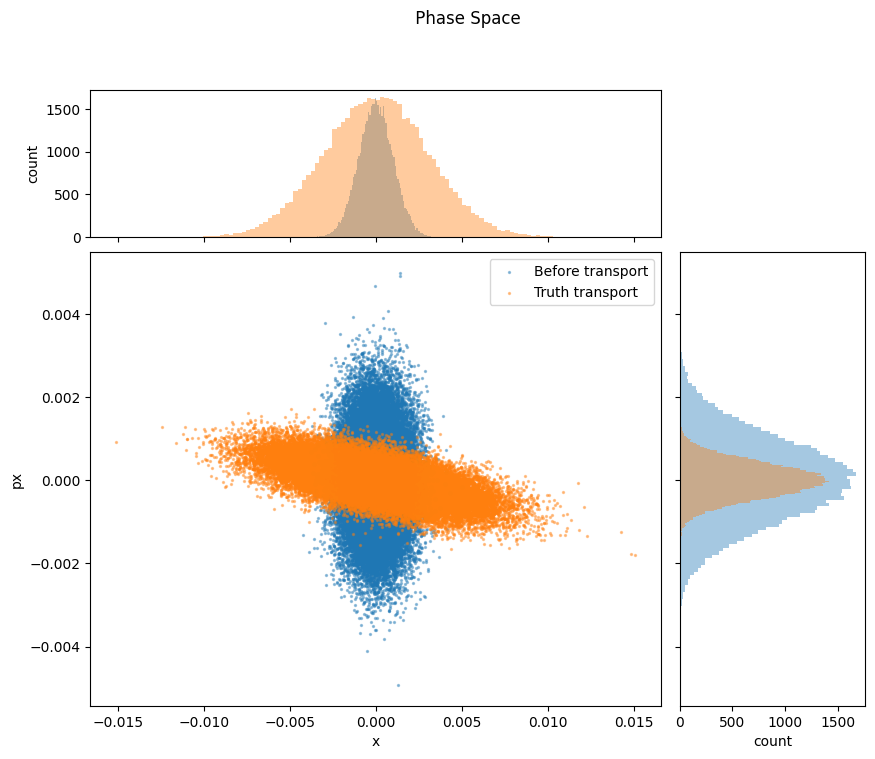

MU shape: (50000, 0)
Initial MSE: 6.0879201914669115e-06
Training set shapes: (50000, 2) (50000, 2)
Test set shapes: (50000, 2) (50000, 2)
Initial weighted MSE: tf.Tensor(1.217584038293386e-05, shape=(), dtype=float64)


In [63]:
data = np.load("xsuite_dataset.npz")

X_raw = data["X"]  # shape (N, 6)
Y = data["Y"]  # shape (N, 6)

print("Original X shape:", X_raw.shape)
print("Original Y shape:", Y.shape)

Z = X_raw[:, :6] #(x,y, zeta, px, py, delta )
MU = X_raw[:, 6:9] # (mu_i)i=1:m


x_array = [Z[:, 0], Y[:, 0]]
px_array = [Z[:, 3], Y[:, 3]]

labels = ["Before transport", "Truth transport"]

plot_phase_space_with_profiles(x_array, px_array, title=" Phase Space", label=labels, difference=False)




print("MU shape:", MU.shape)

dimensions_to_train = [0] #0 = x,px/ 1 = y,py/ 2 = zeta, delta
dimensions_to_train = dimensions_to_train + [i+3 for i in dimensions_to_train]

list_train = [Z[:, i:i+1] for i in  dimensions_to_train]
list_label = [Y[:, i:i+1] for i in dimensions_to_train]


data = tf.concat(list_train, axis = 1)
labels = tf.concat(list_label, axis = 1)

mse_initial = np.mean(np.abs((data - labels))**2)
print("Initial MSE:", mse_initial)

print("Training set shapes:", data.shape, labels.shape)
print("Test set shapes:",data.shape, labels.shape)

w_mse_initial = weighted_outer_mse(data, labels)
print("Initial weighted MSE:", w_mse_initial)



In [65]:

####### Train the HenonNet
def schedulerHenon(epoch):
        if epoch < 100:
            return 1e-3
        elif epoch < 300:
            return 6e-4
        elif epoch < 400:
            return 2e-4
        elif epoch < 500:
            return 5e-5
        elif epoch < 1000:
            return 1e-5
        elif epoch < 3000:
            return 4e-6
        else:
            return 1e-6


loss_fun = weighted_outer_mse

core = HenonNet(unit_list=[16, 16], dim=1)
model = WrappedHenonNet(core=core, dim=1, mu_dim=0)


print('trainable variables count BEFORE compile:', len(model.trainable_variables))
for v in model.trainable_variables[:10]:
    print(v.name, v.shape)

dummy = model(data)
print('trainable variables count AFTER compile:', len(model.trainable_variables))
for v in model.trainable_variables[:10]:
    print(v.name, v.shape)




early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=1e-8,
    restore_best_weights=True,
    verbose=1
)

callback = tf.keras.callbacks.LearningRateScheduler(schedulerHenon)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-4,
        clipnorm=1.0
    ),
    loss= keras.losses.MeanSquaredError,
    run_eagerly=False
)

history = model.fit(
    data, labels,
    batch_size=1250,
    epochs=500,
    validation_split=0.4,
    verbose=2,
    callbacks=[callback]
)





trainable variables count BEFORE compile: 0
trainable variables count AFTER compile: 14
log_s (1,)
cq (1,)
cp (1,)
log_s (1,)
cq (1,)
cp (1,)
Win (1, 16)
Wout (16, 1)
bin (16,)
eta (1,)
Epoch 1/500
24/24 - 7s - 300ms/step - loss: 3.4446e-05 - val_loss: 1.0042e-05 - learning_rate: 1.0000e-03
Epoch 2/500
24/24 - 0s - 8ms/step - loss: 8.1631e-06 - val_loss: 5.8865e-06 - learning_rate: 1.0000e-03
Epoch 3/500
24/24 - 0s - 8ms/step - loss: 6.1867e-06 - val_loss: 5.8647e-06 - learning_rate: 1.0000e-03
Epoch 4/500
24/24 - 0s - 8ms/step - loss: 6.0622e-06 - val_loss: 5.8662e-06 - learning_rate: 1.0000e-03
Epoch 5/500
24/24 - 0s - 7ms/step - loss: 6.0532e-06 - val_loss: 5.8651e-06 - learning_rate: 1.0000e-03
Epoch 6/500
24/24 - 0s - 8ms/step - loss: 6.0527e-06 - val_loss: 5.8634e-06 - learning_rate: 1.0000e-03
Epoch 7/500
24/24 - 0s - 8ms/step - loss: 6.0524e-06 - val_loss: 5.8632e-06 - learning_rate: 1.0000e-03
Epoch 8/500
24/24 - 0s - 8ms/step - loss: 6.0556e-06 - val_loss: 5.8624e-06 - learni

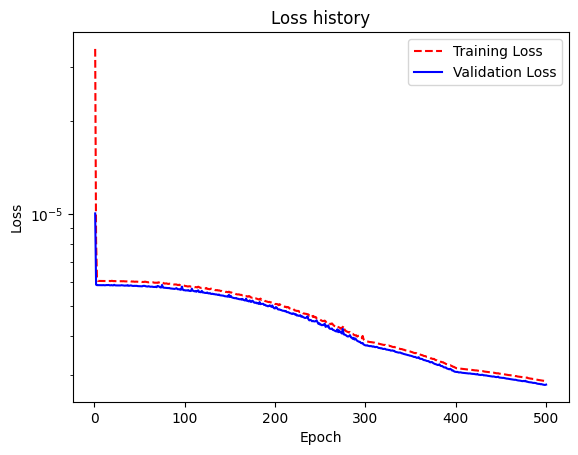

In [67]:
# Get training loss histories
training_loss = history.history['loss']
validation_loss = history.history["val_loss"]
epoch_count = range(1, len(training_loss) + 1) # Visualize loss history
fig0, ax0 = plt.subplots()
plt.plot(epoch_count, training_loss, 'r--', label='Training Loss')
plt.plot(epoch_count, validation_loss, 'b-', label='Validation Loss')
plt.legend()
ax0.set_title('Loss history')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [68]:
pred = test_model.predict(data, verbose=0)

truth = labels.numpy() if hasattr(labels, "numpy") else np.asarray(labels)
inp   = data.numpy()   if hasattr(data, "numpy")   else np.asarray(data)

print("pred shape:", pred.shape)
print("truth shape:", truth.shape)
print("input shape:", inp.shape)


pred shape: (50000, 2)
truth shape: (50000, 2)
input shape: (50000, 2)


In [70]:
mse = np.mean((pred - truth)**2)
print("raw-space MSE:", mse)




raw-space MSE: 0.0018430807213449505


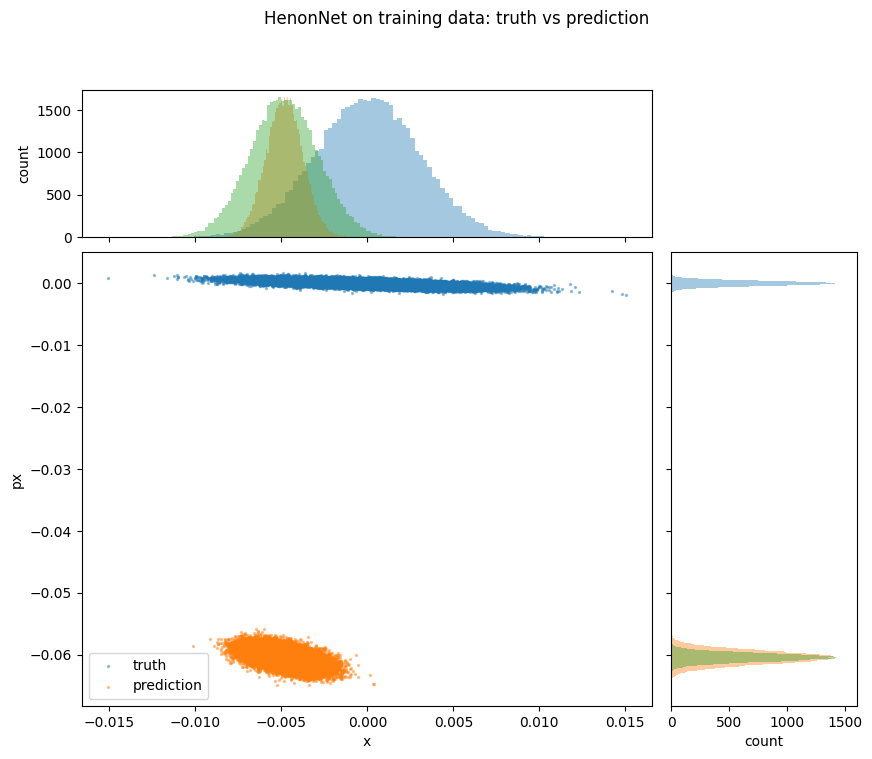

In [71]:
plot_phase_space_with_profiles(
    [truth[:, 0], pred[:, 0]],
    [truth[:, 1], pred[:, 1]],
    title="HenonNet on training data: truth vs prediction",
    axis_labels=["x", "px"],
    label=["truth", "prediction"],
    bins=120,
    difference=True
)